In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, LogisticRegression, LinearSVC, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator
from pyspark.ml.regression import LinearRegression

spark = SparkSession.builder \
    .appName("Semana12_Clasificacion") \
    .getOrCreate()

ruta_datos = "/home/jovyan/work/autotec/luz/Semana 10/modelos/datos_etiquetados_kmeans"

df_clusters = spark.read.parquet(ruta_datos)

df_clusters.show(5)
df_clusters.printSchema()

+-------+--------------------+----+-----------+-----------+--------+-------+---------+----------+---------------+----------+--------------+----------+
|  marca|              modelo|year|kilometraje|combustible|  ciudad| precio|marca_cat|modelo_cat|combustible_cat|ciudad_cat|cluster_kmeans|prediction|
+-------+--------------------+----+-----------+-----------+--------+-------+---------+----------+---------------+----------+--------------+----------+
|peugeot|508 Peugeot 508 2...|2016|    84300.0|     diesel|santiago|1.598E7|       57|        58|              1|        70|             1|         1|
|peugeot|    Landtrek Hdi 1.9|2023|    70750.0|     diesel|santiago|1.195E7|       57|       403|              1|        70|             0|         0|
|peugeot|Landtrek Hdi 1.9 4x4|2023|   101000.0|     diesel|santiago|1.299E7|       57|       404|              1|        70|             0|         0|
|peugeot|Landtrek Hdi 1.9 4x4|2023|   119000.0|     diesel|santiago|1.349E7|       57|       4

In [2]:
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

assembler = VectorAssembler(
    inputCols=[
        "marca_cat",
        "modelo_cat",
        "year",
        "kilometraje",
        "combustible_cat",
        "ciudad_cat",
        "precio"
    ],
    outputCol="features"
)

df_vector = assembler.transform(df_supervisado)

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures"
)

scaler_model = scaler.fit(df_vector)
df_supervisado = scaler_model.transform(df_vector)

train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print("Registros entrenamiento:", train_data.count())
print("Registros prueba:", test_data.count())
    

Registros entrenamiento: 1384
Registros prueba: 571


In [3]:

dt = DecisionTreeClassifier(
    featuresCol="scaledFeatures",
    labelCol="label",
    maxDepth=5,
    seed=42
)

dt_model = dt.fit(train_data)
predicciones_dt = dt_model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy_dt = evaluator.evaluate(predicciones_dt)

print(f"Accuracy Árbol de Decisión: {accuracy_dt * 100:.2f}%")

Accuracy Árbol de Decisión: 90.89%


In [4]:
print("=== ESTRUCTURA DEL ÁRBOL DE DECISIÓN ===")
print(dt_model.toDebugString)

=== ESTRUCTURA DEL ÁRBOL DE DECISIÓN ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_3fe911b35058, depth=5, numNodes=43, numClasses=3, numFeatures=7
  If (feature 3 <= 1.6502260861826832)
   If (feature 5 <= 1.9762859016632355)
    If (feature 5 <= 1.521967303579733)
     If (feature 6 <= 0.6206206822392091)
      Predict: 1.0
     Else (feature 6 > 0.6206206822392091)
      If (feature 1 <= 0.12589454300073097)
       Predict: 1.0
      Else (feature 1 > 0.12589454300073097)
       Predict: 2.0
    Else (feature 5 > 1.521967303579733)
     If (feature 4 <= 0.9011778279234282)
      If (feature 2 <= 568.2226331315683)
       Predict: 1.0
      Else (feature 2 > 568.2226331315683)
       Predict: 0.0
     Else (feature 4 > 0.9011778279234282)
      Predict: 2.0
   Else (feature 5 > 1.9762859016632355)
    If (feature 4 <= 2.7035334837702845)
     If (feature 2 <= 568.2226331315683)
      If (feature 0 <= 2.361041322380765)
       Predict: 0.0
      Else (feature 0 > 2.36

In [5]:
rf = RandomForestClassifier(
    featuresCol="scaledFeatures",
    labelCol="label",
    numTrees=30,
    maxDepth=5,
    seed=42
)

rf_model = rf.fit(train_data)

predicciones_rf = rf_model.transform(test_data)

accuracy_rf = evaluator.evaluate(predicciones_rf)

print(f"Accuracy Random Forest: {accuracy_rf * 100:.2f}%")

Accuracy Random Forest: 95.10%


In [6]:
lr = LogisticRegression(
    featuresCol="scaledFeatures",
    labelCol="label",
    maxIter=20
)

lr_model = lr.fit(train_data)

predicciones_lr = lr_model.transform(test_data)

accuracy_lr = evaluator.evaluate(predicciones_lr)

print(f"Accuracy Regresión Logística: {accuracy_lr * 100:.2f}%")

Accuracy Regresión Logística: 99.12%


In [7]:
print("=========================================")
print("RESULTADOS CLASIFICACIÓN SUPERVISADA")
print("=========================================")
print(f"Árbol de Decisión:      {accuracy_dt * 100:.2f}%")
print(f"Random Forest:          {accuracy_rf * 100:.2f}%")
print(f"Regresión Logística:    {accuracy_lr * 100:.2f}%")
print("=========================================")

print("""
Interpretación:
En esta etapa se utilizaron los clusters creados en Semana 10 como etiquetas para entrenar modelos supervisados.
El objetivo fue evaluar si los modelos son capaces de aprender los patrones creados por K-Means a partir de variables como precio, kilometraje, año, marca y combustible.
Un mayor accuracy indica que el modelo logra replicar mejor la segmentación generada previamente.
""")

RESULTADOS CLASIFICACIÓN SUPERVISADA
Árbol de Decisión:      90.89%
Random Forest:          95.10%
Regresión Logística:    99.12%

Interpretación:
En esta etapa se utilizaron los clusters creados en Semana 10 como etiquetas para entrenar modelos supervisados.
El objetivo fue evaluar si los modelos son capaces de aprender los patrones creados por K-Means a partir de variables como precio, kilometraje, año, marca y combustible.
Un mayor accuracy indica que el modelo logra replicar mejor la segmentación generada previamente.



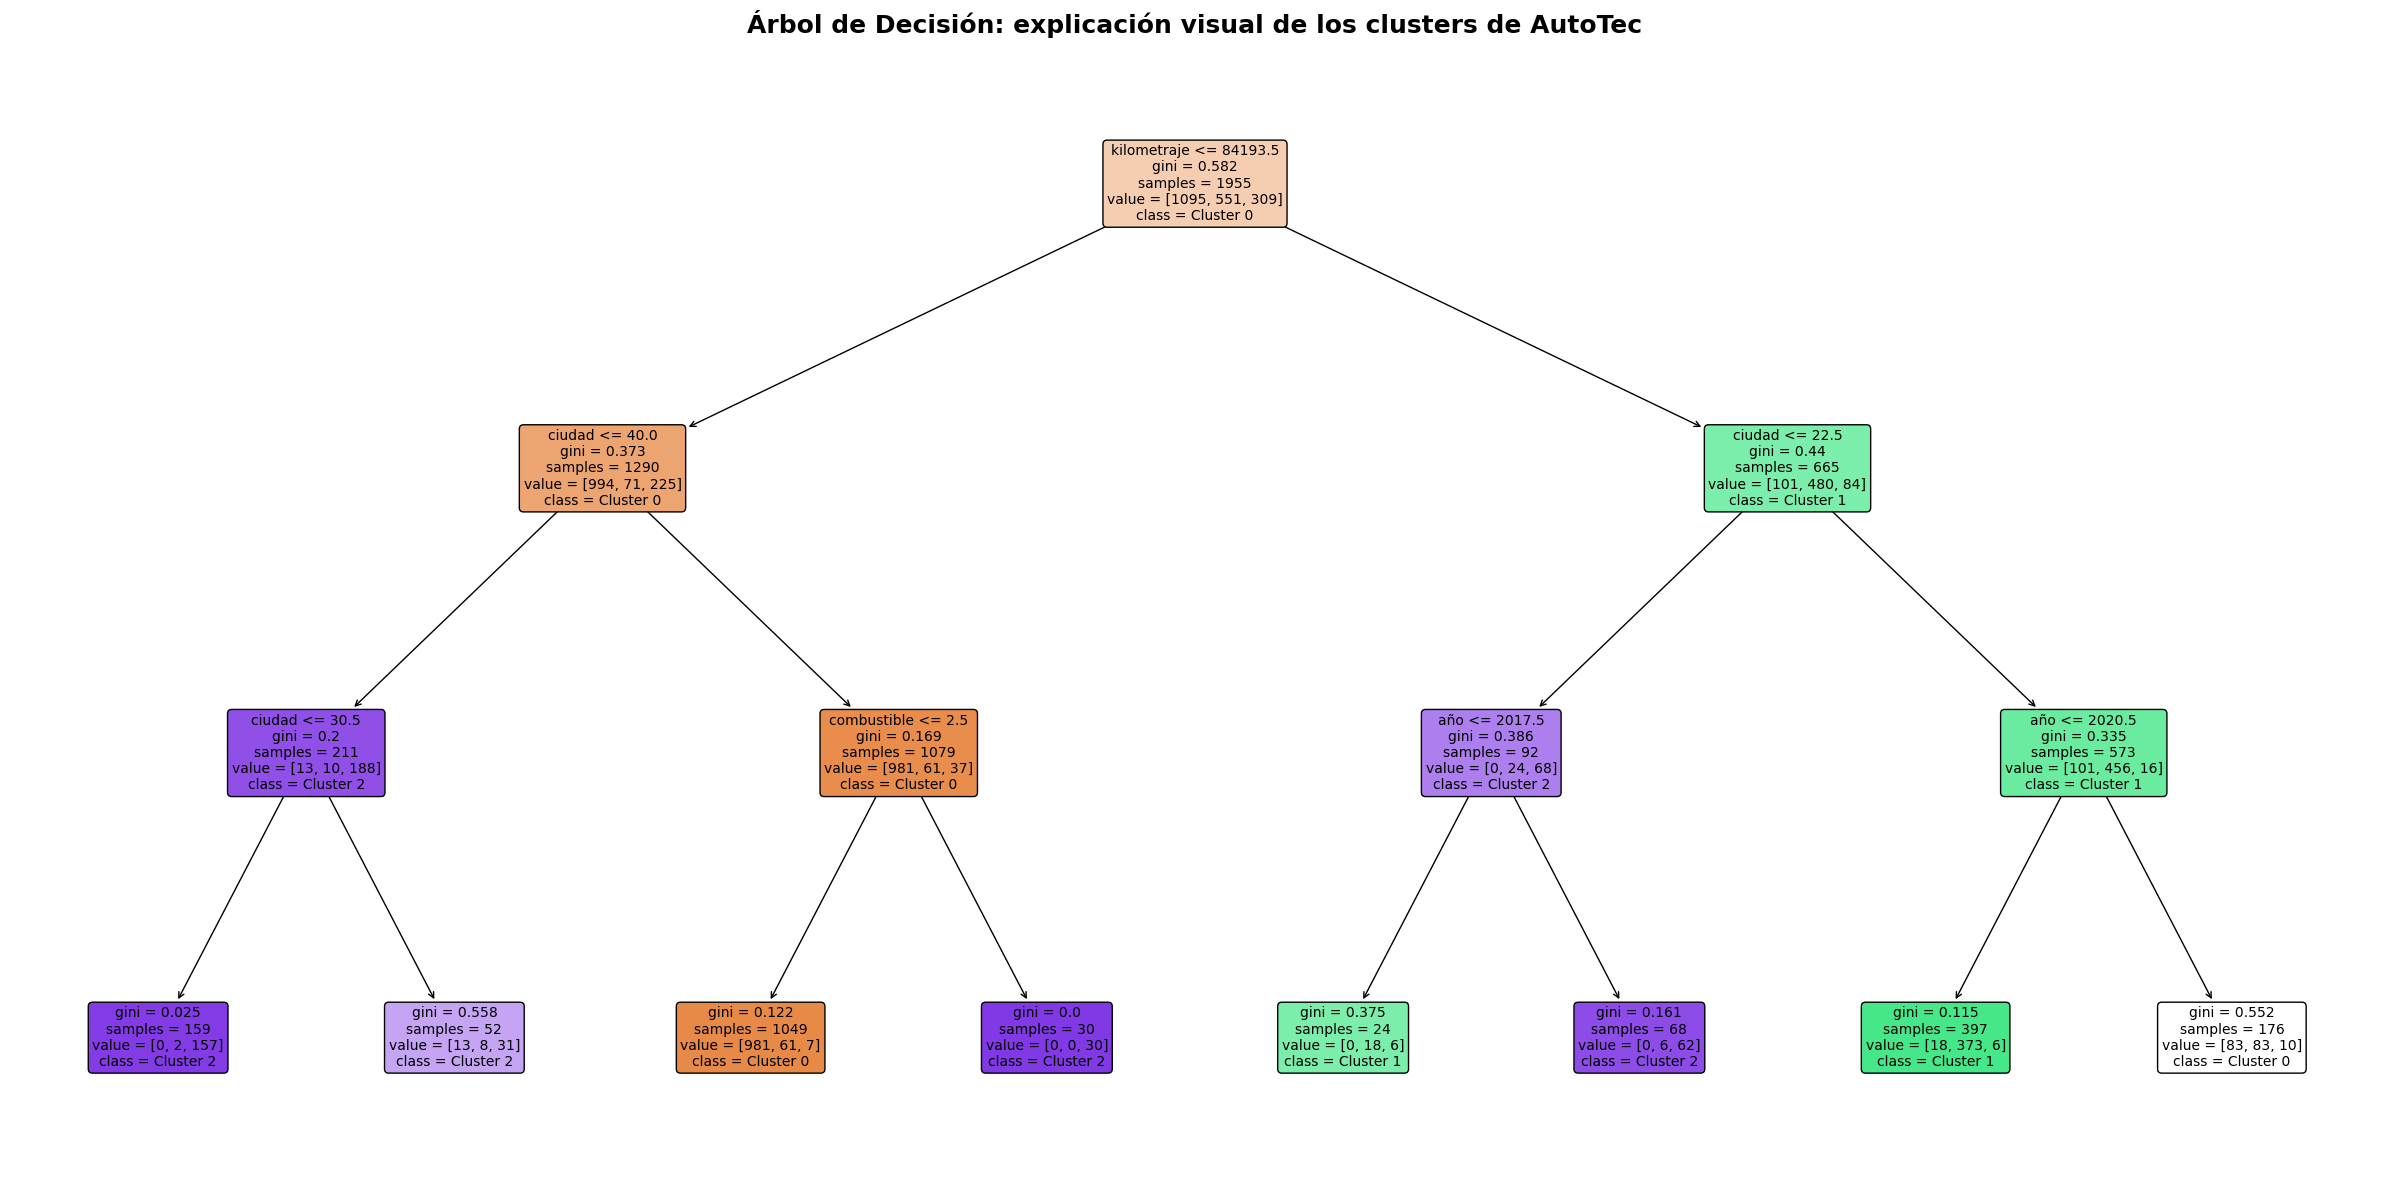

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

df_pandas = df_supervisado.select(
    "precio",
    "kilometraje",
    "year",
    "marca_cat",
    "modelo_cat",
    "combustible_cat",
    "ciudad_cat",
    "label"
).toPandas()

X_muestra = df_pandas[
    [
        "precio",
        "kilometraje",
        "year",
        "marca_cat",
        "modelo_cat",
        "combustible_cat",
        "ciudad_cat"
    ]
]

y_muestra = df_pandas["label"]

sk_dt = SklearnClassifier(
    max_depth=3,
    random_state=42
)

sk_dt.fit(X_muestra, y_muestra)

nombres_features = [
    "precio",
    "kilometraje",
    "año",
    "marca",
    "modelo",
    "combustible",
    "ciudad"
]

nombres_clases = [
    f"Cluster {int(c)}"
    for c in sorted(y_muestra.unique())
]

plt.figure(figsize=(24, 12), dpi=100)

plot_tree(
    sk_dt,
    feature_names=nombres_features,
    class_names=nombres_clases,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title(
    "Árbol de Decisión: explicación visual de los clusters de AutoTec",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Interpretación de Resultados

El árbol de decisión permite identificar qué variables influyen con mayor fuerza en la clasificación de los vehículos dentro de los clusters generados previamente por K-Means.

En el caso de AutoTec, variables como el precio, el kilometraje, el año de fabricación, la marca y el tipo de combustible ayudan a diferenciar los distintos grupos de automóviles presentes en la base de datos.

Los resultados obtenidos muestran que el modelo supervisado fue capaz de aprender los patrones detectados en la etapa de clustering, alcanzando una precisión superior al 90%, lo que indica una alta capacidad para reproducir la segmentación generada en Semana 10.

Esta representación facilita la comprensión de cómo los algoritmos de clasificación pueden utilizar información histórica para predecir a qué grupo pertenece un vehículo, apoyando futuros análisis y procesos de toma de decisiones dentro del proyecto AutoTec.

Conclusiones     
Los modelos supervisados lograron aprender adecuadamente la estructura de los clusters generados por K-Means. Entre los algoritmos evaluados, aquel que obtuvo el mayor accuracy demostró una mejor capacidad para reproducir la segmentación creada durante el análisis no supervisado.

Estos resultados evidencian que las variables utilizadas, como precio, kilometraje, año, marca y combustible, contienen información suficiente para distinguir los distintos grupos de vehículos.

Si algún modelo presenta un rendimiento inferior, esto no necesariamente significa que el algoritmo sea deficiente, sino que puede existir información adicional que no está presente en la base de datos y que ayudaría a mejorar la capacidad predictiva del modelo.